In [1]:
import os
import h5py
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
original_df = pd.read_csv('processed_data/expanded_df_formatted.csv')
h5_path = 'processed_data/expanded_spectrograms.h5'

In [3]:
original_df

,working_df_idx,samplename,chunk_id,filepath,primary_label,secondary_labels,matches_primary,matches_secondary,top_class
0,0,1139490-CSA36385-0,0,/kaggle/input/birdclef-2025/train_audio/113949...,1139490,[''],False,False,flrtan1
1,0,1139490-CSA36385-1,1,/kaggle/input/birdclef-2025/train_audio/113949...,1139490,[''],False,False,cubthr
2,0,1139490-CSA36385-2,2,/kaggle/input/birdclef-2025/train_audio/113949...,1139490,[''],False,False,pelcor
3,0,1139490-CSA36385-3,3,/kaggle/input/birdclef-2025/train_audio/113949...,1139490,[''],False,False,blfbun1
4,0,1139490-CSA36385-4,4,/kaggle/input/birdclef-2025/train_audio/113949...,1139490,[''],False,False,cohmar1
...,...,...,...,...,...,...,...,...,...
115352,28562,ywcpar-iNat819873-0,0,/kaggle/input/birdclef-2025/train_audio/ywcpar...,ywcpar,[''],False,False,normoc
115353,28562,ywcpar-iNat819873-1,1,/kaggle/input/birdclef-2025/train_audio/ywcpar...,ywcpar,[''],False,False,sonthr1
115354,28562,ywcpar-iNat819873-2,2,/kaggle/input/birdclef-2025/train_audio/ywcpar...,ywcpar,[''],False,False,galah
115355,28563,ywcpar-iNat922688-0,0,/kaggle/input/birdclef-2025/train_audio/ywcpar...,ywcpar,[''],False,False,yetwoo2


In [10]:
original_df.groupby('primary_label').indices

{'1139490': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 '1192948': array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
        37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63]),
 '1194042': array([64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]),
 '126247': array([75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]),
 '1346504': array([ 88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
        101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
        114, 115, 116, 117, 118, 119, 120, 121]),
 '134933': array([122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
        135, 136]),
 '135045': array([137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
        150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162,
        163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
  

In [19]:
label_indices = original_df.groupby('primary_label').indices

isolation_indices = {}

for label, indices in tqdm(label_indices.items(), total=len(label_indices), position=0, leave=True):

    with h5py.File(h5_path, 'r') as src_h5:
        src_dset = src_h5['spectrograms']

        specs = src_dset[indices]
        X = np.array([spec.flatten() for spec in specs])

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)    

        clf = IsolationForest(contamination=0.05, random_state=42)  # assumes ~5% noise
        noise_flags = clf.fit_predict(X_scaled) == -1

        isolation_indices[label] = indices[~noise_flags]

  4%|█████▌                                                                                                                                         | 8/206 [00:06<02:43,  1.21it/s]Exception ignored in: <function tqdm.__del__ at 0x7f851b840a40>
Traceback (most recent call last):
  File "/home/ariya/.cache/pypoetry/virtualenvs/kaggle-comps-QIoXe-ZZ-py3.12/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/ariya/.cache/pypoetry/virtualenvs/kaggle-comps-QIoXe-ZZ-py3.12/lib/python3.12/site-packages/tqdm/std.py", line 1277, in close
    if self.last_print_t < self.start_t + self.delay:
       ^^^^^^^^^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'last_print_t'
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 206/206 [06:10<00:00,  1.80s/it]


In [ ]:
def plot_filtered_class_proportions(original_df, filtered_df, label_col='primary_label'):
    # the classes toward the left have fewer samples

    original_counts = original_df[label_col].value_counts().sort_index()
    filtered_counts = filtered_df[label_col].value_counts().sort_index()


    all_labels = sorted(original_counts.index.union(filtered_counts.index))
    original_counts = original_counts.reindex(all_labels, fill_value=0)
    filtered_counts = filtered_counts.reindex(all_labels, fill_value=0)

    proportions = filtered_counts / original_counts.replace(0, 1)

    plt.figure(figsize=(20, 6))
    plt.bar(all_labels, proportions, color='steelblue')
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Proportion in Filtered vs Original")
    plt.title("Class Retention in Filtered Dataset Relative to Original")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

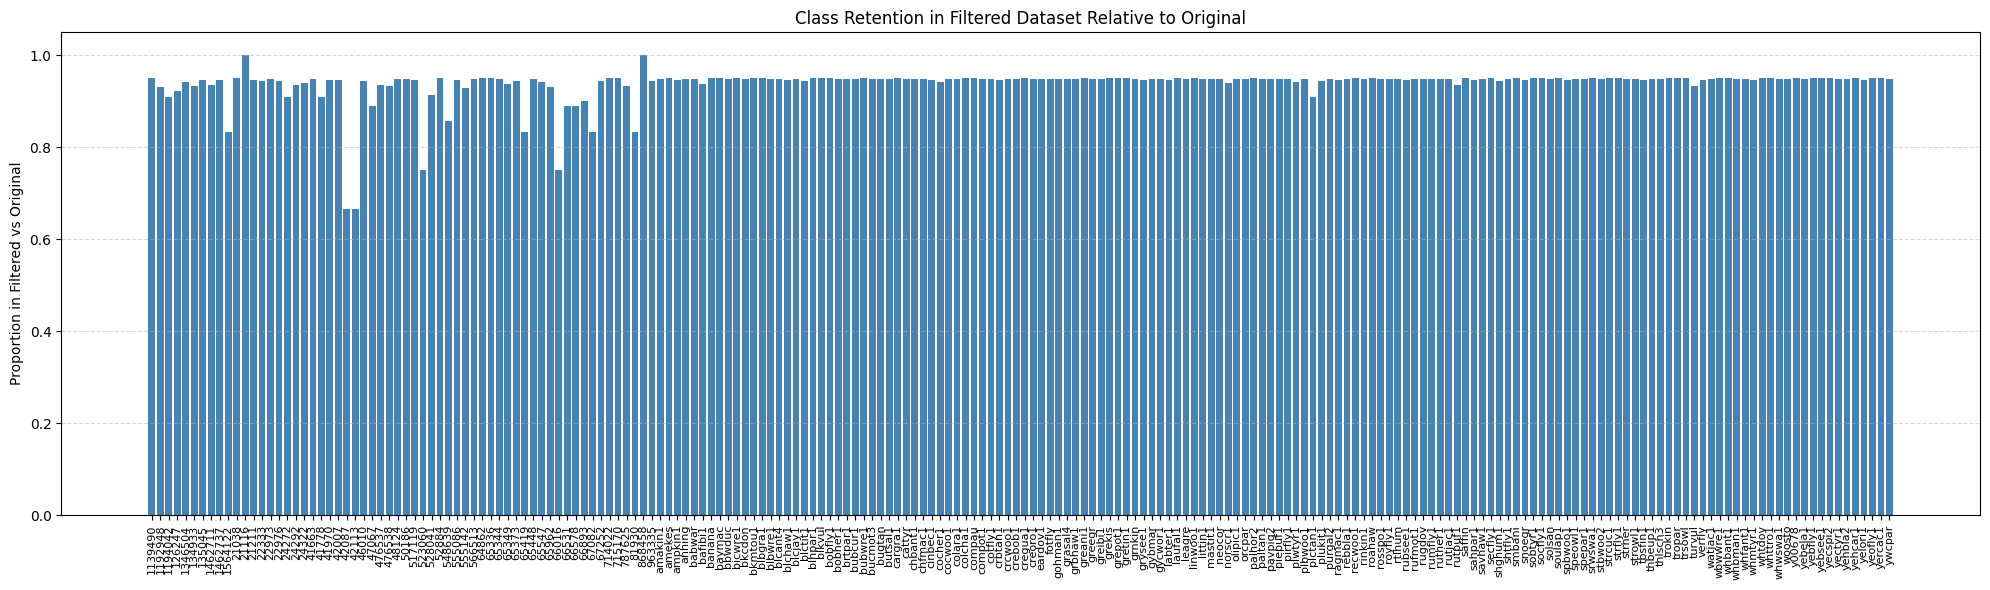

In [25]:
filtered_df = original_df.loc[np.concatenate(list(isolation_indices.values()))]
plot_filtered_class_proportions(original_df, filtered_df)

In [26]:
label_indices = original_df.groupby('primary_label').indices

pca_indices = {}

for label, indices in tqdm(label_indices.items(), total=len(label_indices), position=0, leave=True):

    with h5py.File(h5_path, 'r') as src_h5:
        src_dset = src_h5['spectrograms']

        specs = src_dset[indices]
        X = np.array([spec.flatten() for spec in specs])

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)    

        pca = PCA(n_components=0.95, random_state=42)
        X_pca = pca.fit_transform(X_scaled)

        X_reconstructed = pca.inverse_transform(X_pca)
        reconstruction_errors = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

        noise_flags = reconstruction_errors > np.percentile(reconstruction_errors, 95)
        pca_indices[label] = indices[~noise_flags]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 206/206 [24:34<00:00,  7.16s/it]


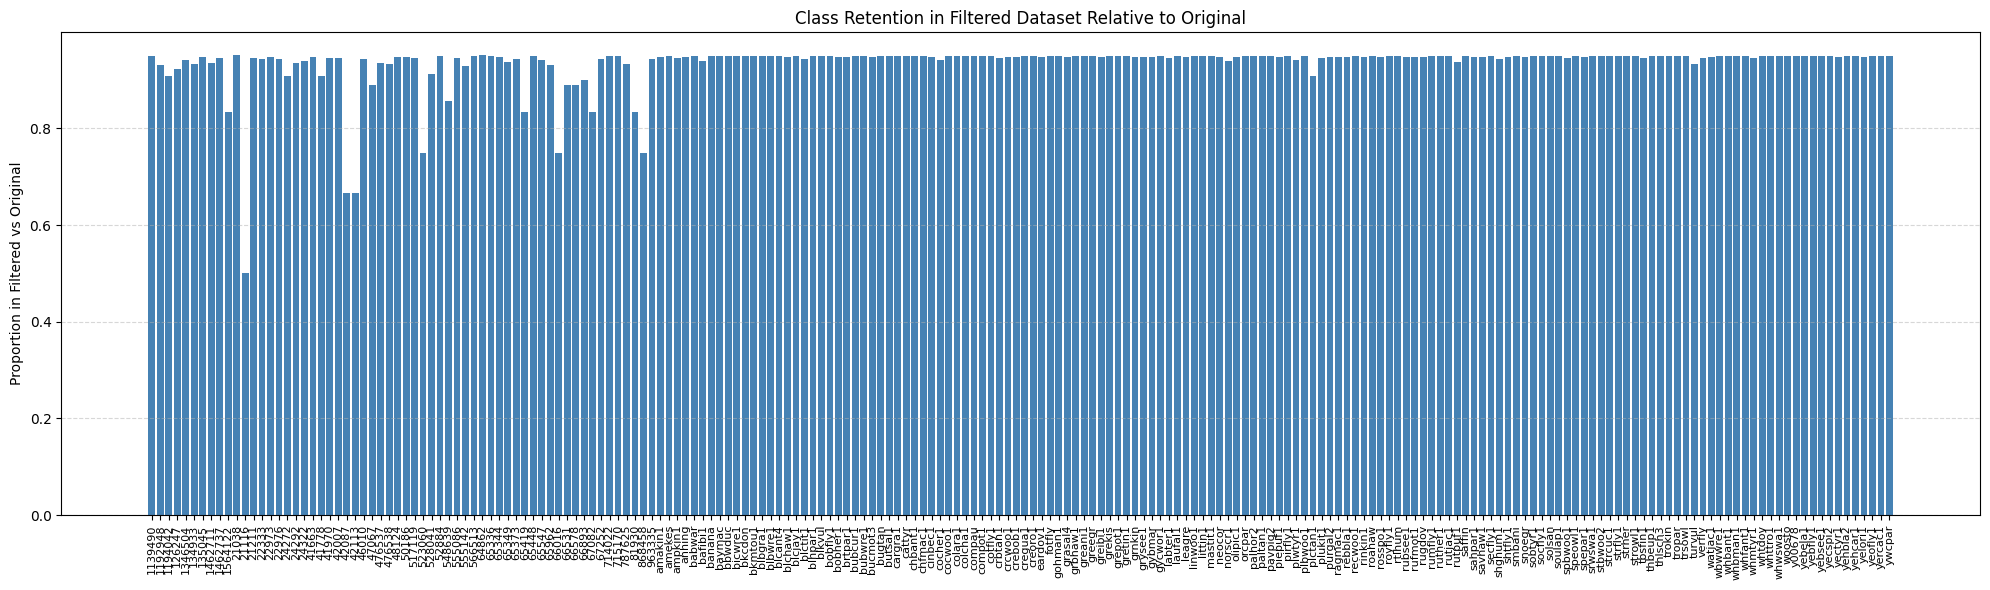

In [27]:
filtered_df = original_df.loc[np.concatenate(list(pca_indices.values()))]
plot_filtered_class_proportions(original_df, filtered_df)